# Olist data EDA

In [5]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import scipy.stats
import numpy as np
from plots import Plotter
import sys
sys.path.append('..')

from src.features.haversine import haversine_distance

### DB connection

In [2]:
conn = duckdb.connect('../data/olist.duckdb')

df = conn.execute("SELECT * FROM analytical_base_table").fetchdf()
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng
0,c31a859e34e3adac22f376954e19b39d,c7b4fb0959a97e7033ff9bef3b1e2ba9,resende,RJ,2018-08-07 23:12:29,6,5,NaN,139.9,59.06,8450,brinquedos,SP,198.96,3,-22.474917,-44.475572,-21.437403,-50.076931
1,9c214ac970e84273583ab523dfafd09b,8c89391790076834500661cc1e5d6860,jacarei,SP,2017-05-08 13:35:48,8,5,NaN,89.9,12.13,1825,casa_conforto,SP,102.03,3,-23.316306,-45.940569,-21.757321,-48.829744
2,f8b6b27efdf0f73f9e9d978fc503c45f,4a4e57e55c5c977bb82ad99a7b6fc190,sao pedro da aldeia,RJ,2018-07-04 16:44:56,7,3,NaN,39.9,19.47,750,cama_mesa_banho,SP,59.37,5,-22.853851,-42.060538,-21.757321,-48.829744
3,93720f5a467d2edd5e84e209e8a9a4f6,9835179d41a3cd33cf230e728fe85798,santos,SP,2018-04-10 22:48:52,8,4,"Uma das peças não encaixava, estava de diâmetr...",79.0,13.46,7225,industria_comercio_e_negocios,SP,92.46,1,-23.969746,-46.321939,-23.493719,-46.546189
4,268762d6a983092f8632e379836806eb,ee87870afcbb29a3c50c068dbd7921a1,campina verde,MG,2017-08-27 13:02:35,10,5,Tudo certo,67.9,28.88,733,relogios_presentes,SC,96.78,3,-19.534302,-49.502095,-26.914469,-49.112263


### Haversine Distancing

In [4]:
df['geo_distance_km'] = haversine_distance(df['customer_lat'], df['customer_lng'], df['seller_lat'], df['seller_lng'])

In [5]:
df.head()

,order_id,customer_unique_id,customer_city,customer_state,order_purchase_timestamp,delivery_days,review_score,review_comment_message,total_price,total_freight_value,product_weight_g,product_category_name,seller_state,total_payment_value,max_installments,customer_lat,customer_lng,seller_lat,seller_lng,geo_distance_km
0,c31a859e34e3adac22f376954e19b39d,c7b4fb0959a97e7033ff9bef3b1e2ba9,resende,RJ,2018-08-07 23:12:29,6,5,NaN,139.9,59.06,8450,brinquedos,SP,198.96,3,-22.474917,-44.475572,-21.437403,-50.076931,589.032280
1,9c214ac970e84273583ab523dfafd09b,8c89391790076834500661cc1e5d6860,jacarei,SP,2017-05-08 13:35:48,8,5,NaN,89.9,12.13,1825,casa_conforto,SP,102.03,3,-23.316306,-45.940569,-21.757321,-48.829744,343.638076
2,f8b6b27efdf0f73f9e9d978fc503c45f,4a4e57e55c5c977bb82ad99a7b6fc190,sao pedro da aldeia,RJ,2018-07-04 16:44:56,7,3,NaN,39.9,19.47,750,cama_mesa_banho,SP,59.37,5,-22.853851,-42.060538,-21.757321,-48.829744,706.899097
3,93720f5a467d2edd5e84e209e8a9a4f6,9835179d41a3cd33cf230e728fe85798,santos,SP,2018-04-10 22:48:52,8,4,"Uma das peças não encaixava, estava de diâmetr...",79.0,13.46,7225,industria_comercio_e_negocios,SP,92.46,1,-23.969746,-46.321939,-23.493719,-46.546189,57.644087
4,268762d6a983092f8632e379836806eb,ee87870afcbb29a3c50c068dbd7921a1,campina verde,MG,2017-08-27 13:02:35,10,5,Tudo certo,67.9,28.88,733,relogios_presentes,SC,96.78,3,-19.534302,-49.502095,-26.914469,-49.112263,821.601356


## Distribution Plots

In [6]:
len(df[pd.isna(df.delivery_days)])

8

In [7]:
df = df.dropna(subset=['delivery_days'])

In [8]:
delivery_days = df.delivery_days.copy()

print(delivery_days.describe())

count      96773.0
mean     12.503891
std       9.555852
min            0.0
25%            7.0
50%           10.0
75%           16.0
max          210.0
Name: delivery_days, dtype: Float64


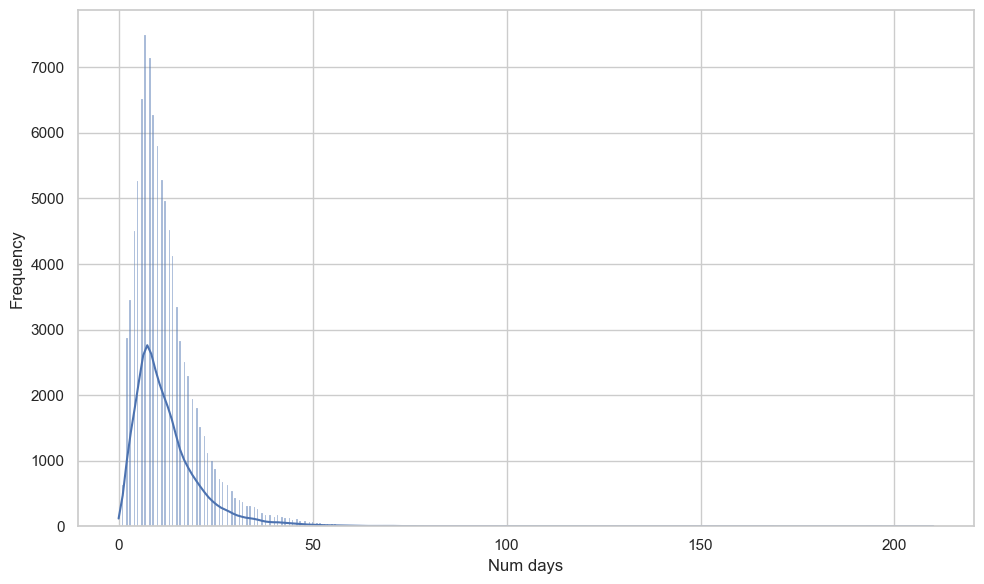

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [9]:
delivery_days_list = delivery_days.copy().tolist()

delivery_plot = Plotter()
delivery_plot.histogram(data=delivery_days_list, xlabel="Num days", ylabel="Frequency", show=True)

In [10]:
extream_delay = delivery_days[delivery_days > 100].copy()
high_delay = delivery_days[(delivery_days > 65) & (delivery_days < 100)].copy()

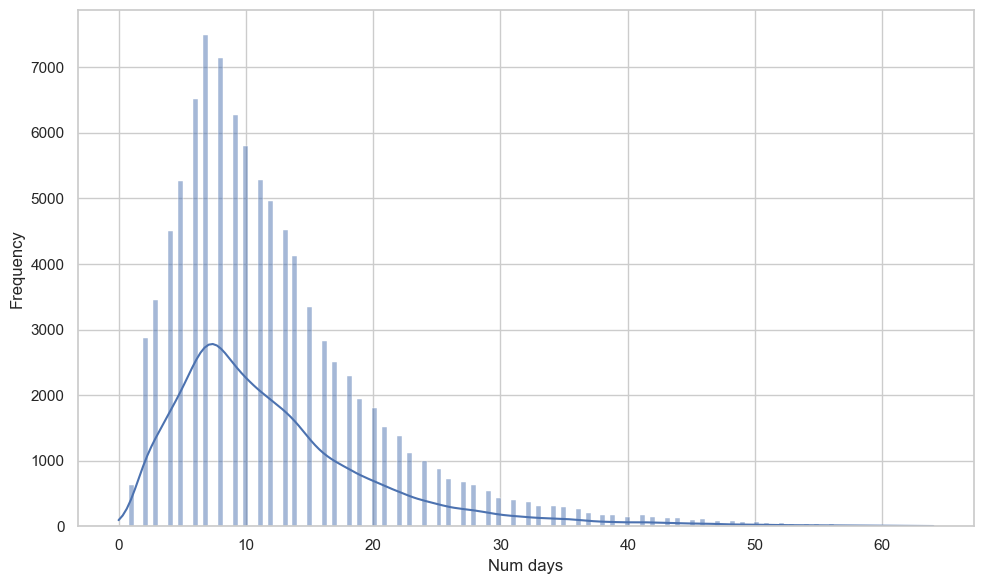

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='Num days', ylabel='Frequency'>)

In [11]:
filtered_delivery_days_list = delivery_days[delivery_days < 65].copy().tolist()

delivery_plot.histogram(data=filtered_delivery_days_list, xlabel="Num days", ylabel="Frequency")

In [12]:
reviews = df.review_score.copy()

print(reviews.describe())

count     96127.0
mean     4.154691
std      1.285599
min           1.0
25%           4.0
50%           5.0
75%           5.0
max           5.0
Name: review_score, dtype: Float64


In [13]:
len(reviews[pd.isna(reviews)])

646

In [14]:
reviews = reviews.dropna()

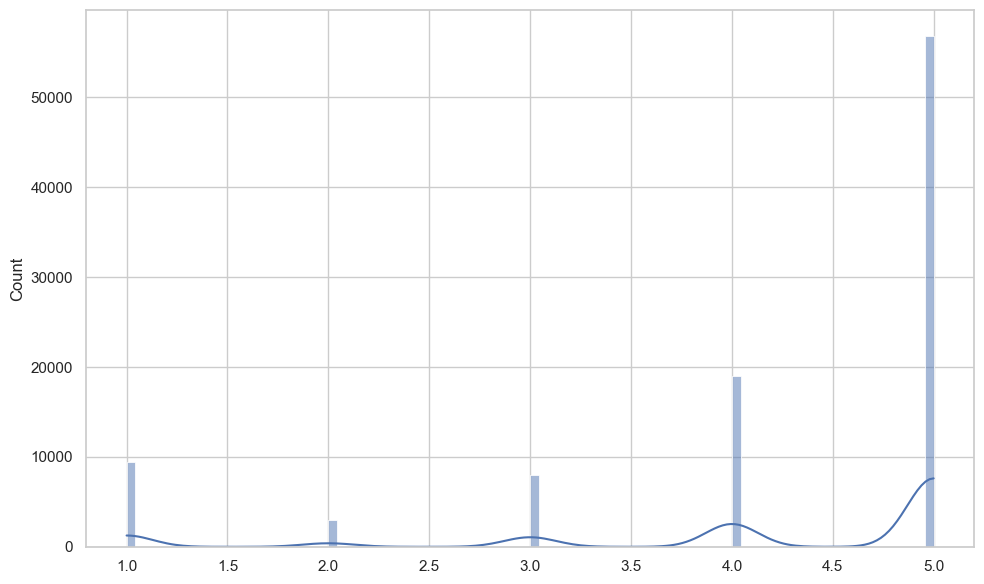

(<Figure size 1000x600 with 1 Axes>, <Axes: ylabel='Count'>)

In [15]:
reviews_s_list = reviews.copy().tolist()

review_plot = Plotter()

review_plot.histogram(reviews_s_list)

In [16]:
feature_df = df.copy()

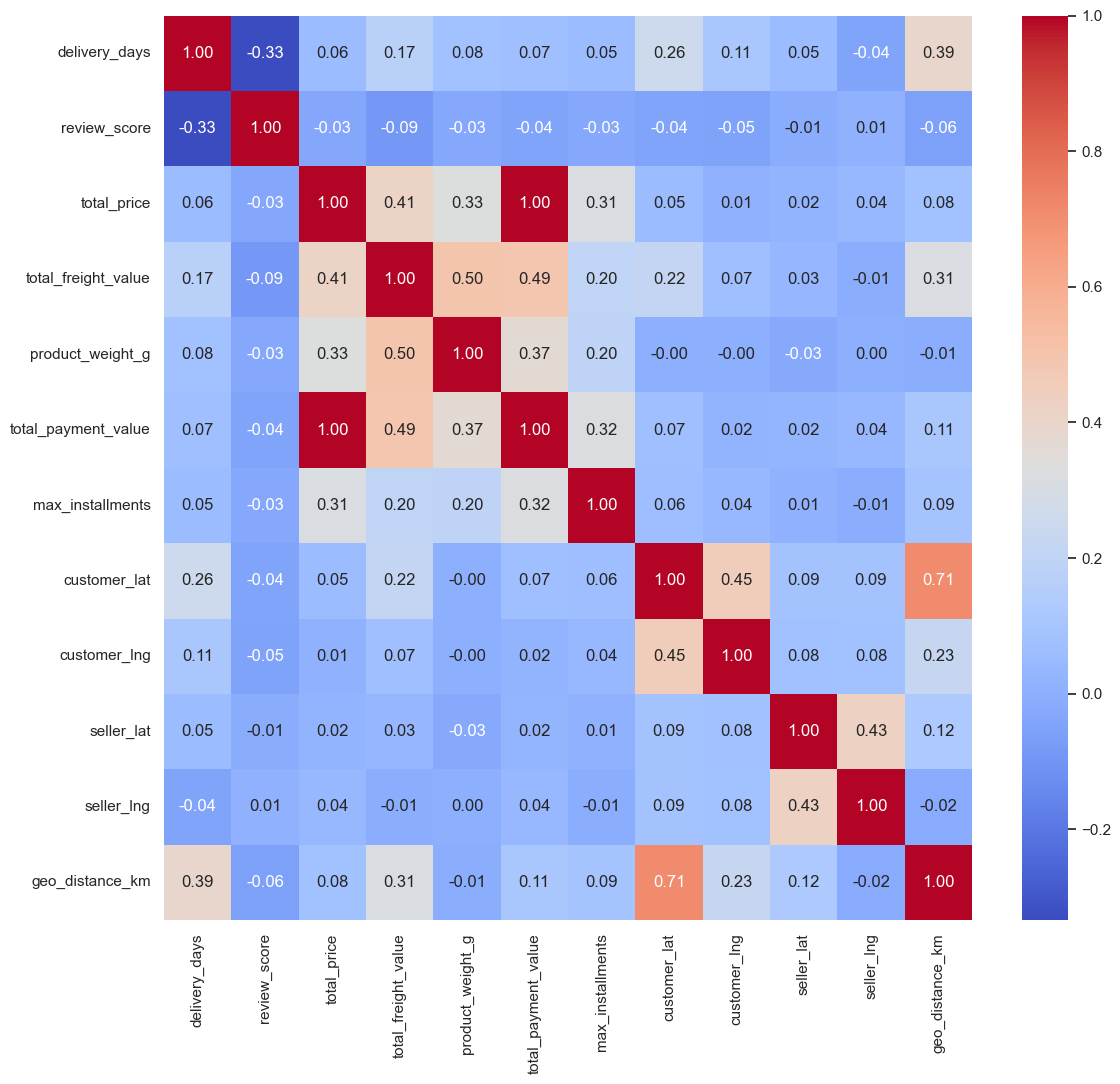

(<Figure size 1200x1100 with 2 Axes>, <Axes: >)

In [17]:
heatmap = Plotter()

heatmap.heatmap(data=feature_df)

In [18]:
deliveries_df = df.copy()[['order_purchase_timestamp', 'delivery_days']]

In [19]:
deliveries_df.head()

,order_purchase_timestamp,delivery_days
0,2018-08-07 23:12:29,6
1,2017-05-08 13:35:48,8
2,2018-07-04 16:44:56,7
3,2018-04-10 22:48:52,8
4,2017-08-27 13:02:35,10


In [20]:
deliveries_df.order_purchase_timestamp = pd.to_datetime(deliveries_df.order_purchase_timestamp)

In [21]:
deliveries_df['day_of_week'] = deliveries_df.order_purchase_timestamp.dt.day_name()
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week
0,2018-08-07 23:12:29,6,Tuesday
1,2017-05-08 13:35:48,8,Monday
2,2018-07-04 16:44:56,7,Wednesday
3,2018-04-10 22:48:52,8,Tuesday
4,2017-08-27 13:02:35,10,Sunday


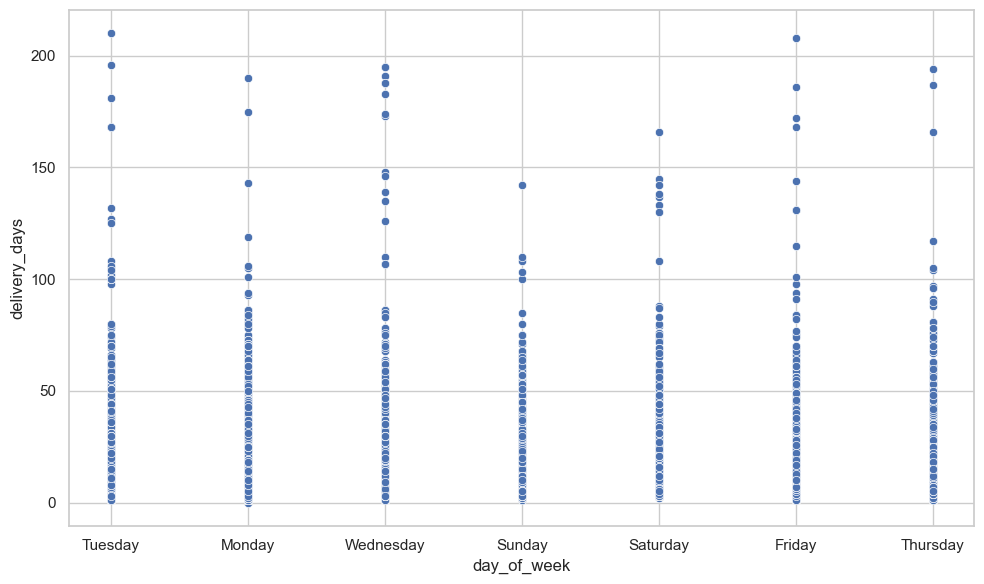

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='day_of_week', ylabel='delivery_days'>)

In [22]:
dow, dd = deliveries_df.copy()['day_of_week'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=dow, y=dd)

In [23]:
deliveries_df['hour_of_day'] = deliveries_df.order_purchase_timestamp.dt.hour
deliveries_df.head()

,order_purchase_timestamp,delivery_days,day_of_week,hour_of_day
0,2018-08-07 23:12:29,6,Tuesday,23
1,2017-05-08 13:35:48,8,Monday,13
2,2018-07-04 16:44:56,7,Wednesday,16
3,2018-04-10 22:48:52,8,Tuesday,22
4,2017-08-27 13:02:35,10,Sunday,13


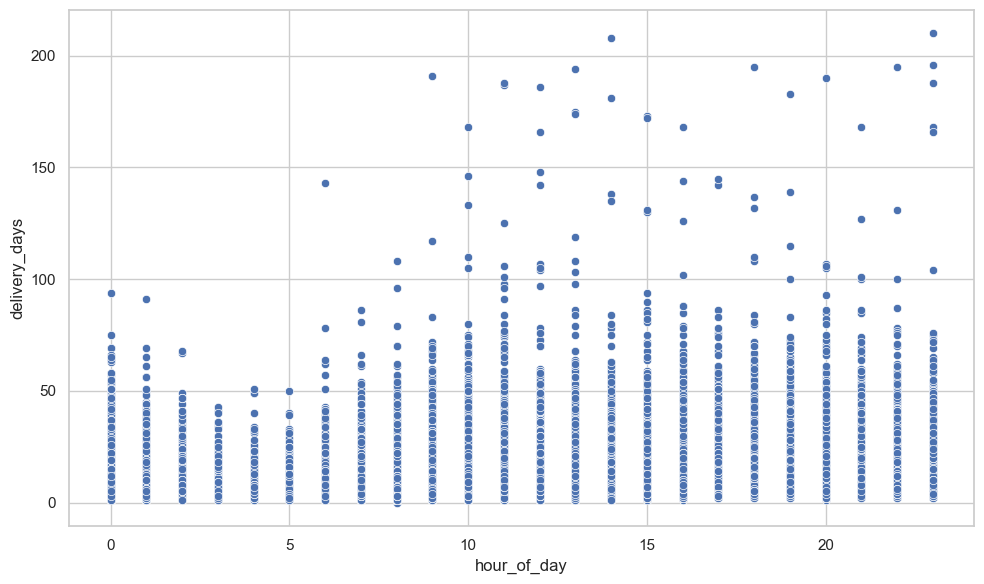

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='hour_of_day', ylabel='delivery_days'>)

In [24]:
hod, dd = deliveries_df.copy()['hour_of_day'], deliveries_df.copy().delivery_days
delivery_plot.scatter(x=hod, y=dd)